# Metadata EDA and Manifest

**Purpose.** Work only with the two metadata tables. Build the UTSW training manifest with patient-level cross-validation folds. Creating the manifest now allows for streamlined reproducibility and creates a connection between the images and patients. Secondly, this notebook checks how many patients, how many IDH-mutant vs wildtype, how many labels are missing, how age and sex relate to IDH, how to count each UCSF patient once, and how different the two cohorts are.

This notebook is split into 3 parts (A-C). **Part A:** Initial UTSW metadata EDA and creating the manifest. **Part B:** UCSF and UTSW metadata EDA. **Part C:** saves the files. 

## Part A: UTSW training manifest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from src import config

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

for f in (config.METADATA_TSV, config.UCSF_METADATA_CSV):
    assert f.exists(), f"Missing {f.name}: copy it into the Data/ folder"

### Load UTSW and look at the columns names
**Why:** confirm the row count, that `Subject ID` has one row per patient, and check any missing values and see the raw spellings of each category before coding anything. 

In [2]:
utsw = pd.read_csv(config.METADATA_TSV, sep="\t")
print("shape:", utsw.shape, "| Subject IDs unique:", utsw["Subject ID"].is_unique)
print(utsw.columns.tolist())


for col in ["IDH", "IDH_Testing Method", "Operation Status", "Manually Refined Segmentation",
            "Scanner Make", "Scanner Strength"]:
    print(utsw[col].value_counts(dropna=False))
    print()
print(utsw[["Age at Imaging", "Sex at birth"]].describe(include="all"))

shape: (625, 21) | Subject IDs unique: True
['Subject ID', 'Sex at birth', 'Age at Imaging', 'Race', 'Ethnicity', 'Tumor Type', 'Pathology Information', 'Tumor Grade', 'IDH', 'IDH_Testing Method', '1p19Q CODEL', 'MGMT', 'Operation Status', 'T1', 'T1GD', 'T2', 'T2FLAIR', 'Scanner Make', 'Scanner Model', 'Scanner Strength', 'Manually Refined Segmentation']
IDH
wild type    446
mutated      176
NaN            3
Name: count, dtype: int64

IDH_Testing Method
IHC    413
NGS    209
NaN      3
Name: count, dtype: int64

Operation Status
PRE    625
Name: count, dtype: int64

Manually Refined Segmentation
Yes    362
No     263
Name: count, dtype: int64

Scanner Make
Siemens         268
GE              172
Philips         141
Not Reported     28
Hitachi          15
Toshiba           1
Name: count, dtype: int64

Scanner Strength
1.5             383
3               197
Not Reported     28
0.7               6
1.16              5
1                 3
0.3               2
0.94999999        1
Name: count

### Rename, code the IDH label, apply exclusions
**Why:** rename column names short consistent with no spaces; converting `IDH` target into binary labels: `idh = 1` for mutant and `0` for wildtype; and patients without an IDH label or with a missing contrast are dropped, with the counts printed so the exclusions can be reported.

In [3]:
# create manifest (which is defined as 'm'); rename columns; final column selection 
# will happen during save time. 
m = utsw.rename(columns={"Subject ID": "patient_id", "Age at Imaging": "age", "Sex at birth": "sex",
                         "IDH_Testing Method": "idh_method", "Scanner Make": "scanner_make",
                         "Scanner Strength": "field_strength",
                         "Manually Refined Segmentation": "has_manual_seg"})

# map IDH values to binary labels
IDH_MAP = {"mutated": 1, "wild type": 0}          # NaN (missing in the file) stays missing
unexpected = set(m["IDH"].dropna().unique()) - set(IDH_MAP)
assert not unexpected, f"Unrecognised UTSW IDH values: {unexpected}"
m["idh"] = m["IDH"].map(IDH_MAP)

# checks that all the contrasts are available for each patient
contrast_cols = ["T1", "T1GD", "T2", "T2FLAIR"]
print("not 'Available' per contrast:\n", (m[contrast_cols] != "Available").sum())

# filter out patients with missing IDH and/or missing contrasts
n_utsw_total = len(m)
m = m[m["idh"].notna() & (m[contrast_cols] == "Available").all(axis=1)].reset_index(drop=True)
m["idh"] = m["idh"].astype(int)
print(f"kept {len(m)} of {n_utsw_total}") # 3 subjects dropped, consistent with the 3 NaN IDH values found earlier

print("missing age / sex among kept:", m[["age", "sex"]].isna().sum().to_dict()) # checks subjects with missing age or sex

not 'Available' per contrast:
 T1         0
T1GD       0
T2         0
T2FLAIR    0
dtype: int64
kept 622 of 625
missing age / sex among kept: {'age': 0, 'sex': 0}


### What method was used to test IDH?

**IHC / NGS Test Methods**: two lab methods for deciding IDH status. IHC (immunohistochemistry) uses an antibody stain; NGS (next-generation sequencing) reads the gene's DNA sequence.

**Why:** The test method used could be impact label quality. While it will *not* be used as a feature, later results may need reporting by testing method.

In [4]:
display(pd.crosstab(utsw["IDH_Testing Method"].fillna("missing"), utsw["IDH"].fillna("missing")))

IDH,missing,mutated,wild type
IDH_Testing Method,,,
IHC,0,104,309
NGS,0,72,137
missing,3,0,0


### Coarse scanner group
**Why:** UTSW mixes vendors and field strengths (0.3 T to 3 T). A model can learn "which scanner" instead of tumor biology, so we keep a coarse group for subgroup reporting. Anything that is not exactly 1.5 T or 3 T becomes `other`; text such as "Not Reported" becomes `unreported`. The scanner strength will *not* be used as a feature. 

In [5]:
fs = pd.to_numeric(m["field_strength"], errors="coerce")   # text like "Not Reported" becomes NaN
m["scanner_group"] = "other"
m.loc[fs == 1.5, "scanner_group"] = "1.5T"
m.loc[fs == 3, "scanner_group"] = "3T"
m.loc[fs.isna(), "scanner_group"] = "unreported"
print(m["scanner_group"].value_counts().to_dict())

{'1.5T': 380, '3T': 197, 'unreported': 28, 'other': 17}


### Patient-level folds
**Why:** cross-validation inside UTSW is how we tune without touching UCSF. Each row is one patient, so splitting rows splits patients, and no patient can sit on both sides of a split. Folds are stratified by IDH so every fold has about the same mutant rate. The fixed seed makes the split reproducible.

In [6]:
m["fold"] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# assign folds to each patient, stratified by IDH status
for k, (_, val_idx) in enumerate(skf.split(m, m["idh"])):
    m.loc[val_idx, "fold"] = k

# check that all folds are non-negative (meaning they were properly assigned a fold)
# and that patient IDs are unique
assert (m["fold"] >= 0).all() and m["patient_id"].is_unique

print(m.groupby("fold")["idh"].agg(n="size", mutants="sum", rate="mean").round(3))

        n  mutants   rate
fold                     
0     125       35  0.280
1     125       36  0.288
2     124       35  0.282
3     124       35  0.282
4     124       35  0.282


## Part B: UCSF and cohort checks

### Load UCSF and code its IDH label
**Why:** UCSF spells IDH differently (`wildtype`, `mutated (NOS)`, and specific variants such as `IDH1 p.R132H`; NOS means "not otherwise specified": mutation present, exact variant not given). The function maps all of these to the same 0/1 coding and **raises on anything unrecognised**.

The file has 501 rows (scans), but the dataset page says 495 patients, so the row count is not the patient count.

In [7]:
ucsf = pd.read_csv(config.UCSF_METADATA_CSV)
print("rows:", len(ucsf), "| exact duplicate IDs:", ucsf["ID"].duplicated().sum())
print(ucsf["IDH"].value_counts(dropna=False))

# map UCSF IDH values to binary labels
def ucsf_idh_to_binary(value):
    v = str(value).strip().lower()
    if v == "wildtype":
        return 0
    if v.startswith(("idh1", "idh2", "mutated")):
        return 1
    raise ValueError(f"Unrecognised UCSF IDH value: {value!r}")

ucsf["idh"] = ucsf["IDH"].map(ucsf_idh_to_binary)

rows: 501 | exact duplicate IDs: 0
IDH
wildtype            398
IDH1 p.R132H         54
mutated (NOS)        31
IDH1 p.R132C          8
IDH1 p.R132G          5
IDH1 p.R132S          2
IDH2 p.R172K          1
IDH2 p.Arg172Trp      1
IDH1 p.Arg132His      1
Name: count, dtype: int64


### Drop Follow-Up Scans
**Why:** Keep consistent with of one row per patient across datasets. 

Follow-up scans are named `<ID>_FU<days>d`. Their IDs are zero-padded to 4 digits (ex. `UCSF-PDGM-0391_FU016d`) while baseline IDs use 3 digits (`UCSF-PDGM-391`), so stripping only the suffix leaves `0391` vs `391`, which do **not** match. We parse the number as an integer instead. We will keep the baseline scan of each patient. The image folders for follow-up scans use the same naming. Reuse this exact regex when linking image files to patients, otherwise the image side can reintroduce duplicates that this table removed.

In [8]:
# parse UCSF IDs to extract patient number and follow-up days. 
parts = ucsf["ID"].str.extract(r"^UCSF-PDGM-(\d+)(?:_FU(\d+)d)?$")
assert parts[0].notna().all(), "Some IDs do not match the expected pattern"

ucsf["patient_num"] = parts[0].astype(int)
ucsf["is_followup"] = parts[1].notna()
ucsf["followup_days"] = pd.to_numeric(parts[1])

print("rows:", len(ucsf), "| follow-up rows:", int(ucsf["is_followup"].sum()))
print("unique patients after integer parsing:", ucsf["patient_num"].nunique())

# Before dropping any rows, check clinical/label fields should be identical across a patient's scans.
conflicts = ucsf.groupby("patient_num")[["Sex", "Age at MRI", "IDH"]].nunique().gt(1).any(axis=1)
print("patients with conflicting metadata across scans:", int(conflicts.sum()))

# Keep only the first scan (baseline) for each patient
ucsf = (ucsf.sort_values(["patient_num", "is_followup", "followup_days"])
            .drop_duplicates("patient_num", keep="first")
            .rename(columns={"Age at MRI": "age", "Sex": "sex"})
            .reset_index(drop=True))

# Create a new patient ID column with zero-padded patient numbers (has to match image filenames)
ucsf["patient_id"] = "UCSF-PDGM-" + ucsf["patient_num"].astype(str).str.zfill(4)
assert ucsf["patient_id"].is_unique and not ucsf["is_followup"].any()
assert len(ucsf) == 495, f"expected 495 patients (dataset page), got {len(ucsf)}"
print("UCSF patients:", len(ucsf))

rows: 501 | follow-up rows: 6
unique patients after integer parsing: 495
patients with conflicting metadata across scans: 0
UCSF patients: 495


### One cohort table and class balance
**Why:** a shared schema (`dataset, patient_id, age, sex, idh`) makes the comparisons below simple, and it reuses the UTSW table `m` from Part A instead of recoding it. The `UTSW excluded` count covers any patient dropped in the previous cells.

In [9]:
cols = ["dataset", "patient_id", "age", "sex", "idh"]
cohort = pd.concat([m.assign(dataset="UTSW")[cols], ucsf.assign(dataset="UCSF")[cols]], ignore_index=True)

balance = cohort.groupby("dataset")["idh"].agg(labeled="size", mutant="sum")
balance["wildtype"] = balance["labeled"] - balance["mutant"]
balance["prevalence_mutant"] = (balance["mutant"] / balance["labeled"]).round(3)
balance["excluded"] = pd.Series({"UTSW": n_utsw_total - len(m), "UCSF": 0})
display(balance)
print("age range:", cohort.groupby("dataset")["age"].agg(["min", "max"]).to_dict("index"))
print("patients under 18:", cohort.groupby("dataset")["age"].apply(lambda s: int((s < 18).sum())).to_dict())

,labeled,mutant,wildtype,prevalence_mutant,excluded
dataset,,,,,
UCSF,495,103,392,0.208,0
UTSW,622,176,446,0.283,3


age range: {'UCSF': {'min': 17, 'max': 94}, 'UTSW': {'min': 18, 'max': 85}}
patients under 18: {'UCSF': 1, 'UTSW': 0}


### Age by IDH status
**Why:** a model given age can score well without looking at the tumor at all, which is why image-only, clinical-only and fused results are reported side by side.

The "AUROC of age alone" is a **descriptive, same-dataset** number: AUROC is the probability that a random wildtype patient is older than a random mutant patient (0.5 = chance, 1.0 = perfect separation). It is not a model result and uses no train/test split; the real clinical-only baseline comes from notebook 03 with cross-validation. It is computed for **UTSW only**: UCSF is the locked test set, so no number that uses its labels should become a bar to beat.

**Finding:**
- Patients with a IDH mutation are significantly more likely to be younger. 

In [10]:
cohort["idh_label"] = cohort["idh"].map({0: "wildtype", 1: "mutant"})
display(cohort.groupby(["dataset", "idh_label"])["age"].describe().round(1))

# Mann-Whitney U test for age difference between mutant and wildtype patients in UTSW dataset
age_mut, age_wt = m.loc[m["idh"] == 1, "age"], m.loc[m["idh"] == 0, "age"]
u, p = stats.mannwhitneyu(age_mut, age_wt, alternative="two-sided")
auc_age = 1 - u / (len(age_mut) * len(age_wt)) 
print(f"UTSW: median age mutant {age_mut.median():.0f} vs wildtype {age_wt.median():.0f}, "
      f"Mann-Whitney p = {p:.2g}, descriptive AUROC of age alone = {auc_age:.3f}")

count  mean   std   min   25%   50%   75%   max
dataset idh_label                                                 
UCSF    mutant     103.0  38.8  11.5  17.0  31.0  37.0  45.5  71.0
        wildtype   392.0  61.6  12.0  21.0  54.0  62.0  70.0  94.0
UTSW    mutant     176.0  40.0  11.9  20.0  31.0  38.0  48.0  69.0
        wildtype   446.0  60.9  12.5  18.0  54.0  63.0  70.0  85.0

UTSW: median age mutant 38 vs wildtype 63, Mann-Whitney p = 5.6e-49, descriptive AUROC of age alone = 0.878


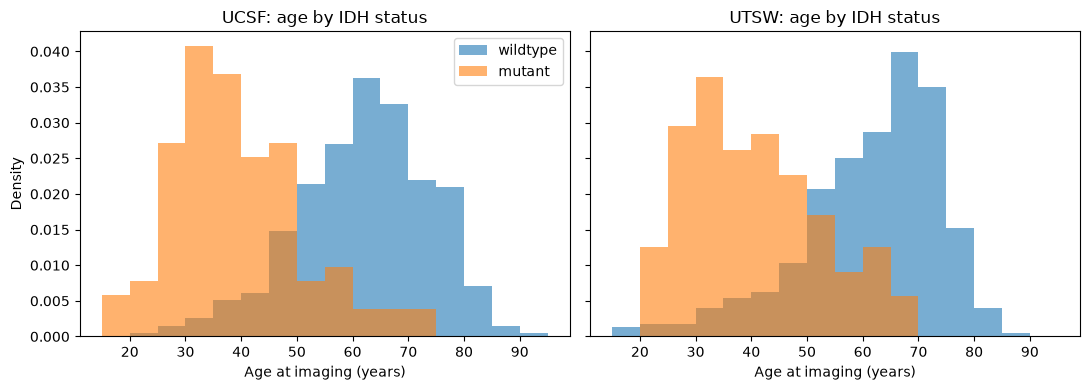

In [11]:
# Plot age distributions by IDH status for each dataset
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bins = np.arange(15, 100, 5)
for ax, (name, g) in zip(axes, cohort.groupby("dataset")):
    for lab, color in [("wildtype", "tab:blue"), ("mutant", "tab:orange")]:
        ax.hist(g.loc[g["idh_label"] == lab, "age"], bins=bins, alpha=0.6, density=True, label=lab, color=color)
    ax.set_title(f"{name}: age by IDH status")
    ax.set_xlabel("Age at imaging (years)")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()
plt.show()

### Sex by IDH status
**Why:** the second allowed clinical feature. We expect little signal but check rather than assume. The chi-square test asks whether sex and IDH status are independent.

In [12]:
for name, g in cohort.groupby("dataset"):
    ct = pd.crosstab(g["sex"], g["idh_label"])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"{name}: chi-square p = {p:.3f}")
    display(ct.assign(mutant_rate=(ct["mutant"] / ct.sum(axis=1)).round(3)))

UCSF: chi-square p = 0.838


idh_label,mutant,wildtype,mutant_rate
sex,,,
F,40,159,0.201
M,63,233,0.213


UTSW: chi-square p = 0.072


idh_label,mutant,wildtype,mutant_rate
sex,,,
F,82,171,0.324
M,94,275,0.255


### How different are the two cohorts?
**Why:** a model trained at one institution and tested at another faces **dataset shift** (different age mix, IDH prevalence, scanners). Quantifying it now tells you what to expect from the external result.

The UTSW tables below also screen for **shortcut risk**: if IDH prevalence differs by vendor, field strength, segmentation-refinement flag or testing method, a CNN could learn that variable instead of tumor biology, even without being directly given as features. 

**Findings:**
- Age distribution in both datasets are similar
- Only scanner vendor and testing method have a noticeable gaps. Especially testing method where NGS has a much higher mutant rate. 

In [13]:
print(cohort.groupby("dataset")["age"].agg(["count", "median", "mean", "std"]).round(1))
u, p = stats.mannwhitneyu(cohort.loc[cohort["dataset"] == "UTSW", "age"],
                          cohort.loc[cohort["dataset"] == "UCSF", "age"])
print(f"Age, UTSW vs UCSF: Mann-Whitney p = {p:.3f}")

for col in ["scanner_group", "scanner_make", "has_manual_seg", "idh_method"]:
    print(f"\nUTSW mutant rate by {col}")
    display(m.groupby(col)["idh"].agg(n="size", mutant_rate="mean").round(3))

         count  median  mean   std
dataset                           
UCSF       495    59.0  56.9  15.1
UTSW       622    58.0  55.0  15.5
Age, UTSW vs UCSF: Mann-Whitney p = 0.111

UTSW mutant rate by scanner_group


,n,mutant_rate
scanner_group,,
1.5T,380,0.289
3T,197,0.269
other,17,0.294
unreported,28,0.286



UTSW mutant rate by scanner_make


,n,mutant_rate
scanner_make,,
GE,171,0.292
Hitachi,15,0.267
Not Reported,28,0.286
Philips,141,0.348
Siemens,266,0.241
Toshiba,1,1.000



UTSW mutant rate by has_manual_seg


,n,mutant_rate
has_manual_seg,,
No,263,0.278
Yes,359,0.287



UTSW mutant rate by idh_method


,n,mutant_rate
idh_method,,
IHC,413,0.252
NGS,209,0.344


### Columns inspected, not used
**Why:** the only model inputs are **age and sex** (known at imaging time). The columns below were inspected and are **never** joined into the manifest or fed to a model:
- **Tumor type / diagnosis, WHO grade, 1p/19q:** defined partly by IDH status (WHO grade is the 1-4 severity grade; 1p/19q codeletion is the loss of two chromosome arms that defines oligodendroglioma, which requires an IDH mutation; general background).
- **MGMT, survival (OS, dead/alive), extent of resection (EOR):** results or outcomes only known after surgery and tissue analysis.
- Scanner fields, testing method, segmentation flag: kept only for subgroup reporting, not as features.

The cell prints two UTSW tables for the record. Zero cells (a row where one IDH class is empty) are what a leak looks like.

In [15]:
NOT_USED = {
    "UTSW": ["Tumor Type", "Pathology Information", "Tumor Grade", "1p19Q CODEL", "MGMT"],
    "UCSF": ["WHO CNS Grade", "Final pathologic diagnosis (WHO 2021)", "1p/19q", "MGMT status", "MGMT index",
             "OS", "1-dead 0-alive", "EOR"],
}
lab = m["idh"].map({1: "mutant", 0: "wildtype"})
for col in ["1p19Q CODEL", "Tumor Grade"]:
    print(f"UTSW: {col} vs IDH")
    display(pd.crosstab(m[col].fillna("not reported"), lab))

UTSW: 1p19Q CODEL vs IDH


idh,mutant,wildtype
1p19Q CODEL,,
co-deleted,63,0
non co-deleted,77,195
not reported,36,251


UTSW: Tumor Grade vs IDH


idh,mutant,wildtype
Tumor Grade,,
2.0,85,16
3.0,64,33
4.0,27,390
not reported,0,7


## Part C: Save

### Save the manifest, the folds and the cleaned UCSF table
**Why:** later notebooks and scripts read these files instead of redoing Parts A and B.
- `manifest.csv` (gitignored): the full UTSW manifest.
- `results/utsw_folds.csv` (committed): `patient_id` and `fold` only, so the split is reproducible without publishing anything else.
- `ucsf_clean.csv` (gitignored): one row per UCSF patient, for the final external test.

The asserts check that no unused column slipped into a saved table and that every fold contains both classes.

In [16]:
m["processed"] = False
keep = ["patient_id", "idh", "age", "sex", "idh_method", "scanner_group", "scanner_make",
        "has_manual_seg", "fold", "processed"]
ucsf_keep = ["patient_id", "age", "sex", "idh"]

banned = set(NOT_USED["UTSW"]) | set(NOT_USED["UCSF"])
assert banned.isdisjoint(keep) and banned.isdisjoint(ucsf_keep)
assert m.groupby("fold")["idh"].nunique().eq(2).all()

for path in (config.MANIFEST, config.SPLITS, config.UCSF_CLEAN):
    path.parent.mkdir(parents=True, exist_ok=True)
m[keep].to_csv(config.MANIFEST, index=False)
m[["patient_id", "fold"]].to_csv(config.SPLITS, index=False)
ucsf[ucsf_keep].to_csv(config.UCSF_CLEAN, index=False)

print("saved:", config.MANIFEST.name, f"({len(m)} patients),", config.SPLITS.name,
      f"({m['fold'].nunique()} folds),", config.UCSF_CLEAN.name, f"({len(ucsf)} patients)")

saved: manifest.csv (622 patients), utsw_folds.csv (5 folds), ucsf_clean.csv (495 patients)
